In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_model import ARIMAResults

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Activation, Dropout
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K

In [ ]:
# Load data source
file_path = '/content/TG_STAID002759.txt'

with open(file_path, 'r') as f:
    lines = f.readlines()

for i, line in enumerate(lines):
  if line.strip().startswith('SOUID'):
      header_index = i
      break

# Now read the data using pandas, starting from that line
df = pd.read_csv(file_path, skiprows=header_index, skipinitialspace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54481 entries, 0 to 54480
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   SOUID   54481 non-null  int64
 1   DATE    54481 non-null  int64
 2   TG      54481 non-null  int64
 3   Q_TG    54481 non-null  int64
dtypes: int64(4)
memory usage: 1.7 MB


In [ ]:
df['DATE'] = pd.to_datetime(df['DATE'], format='%Y%m%d')

In [ ]:
df.head()

,SOUID,DATE,TG,Q_TG
0,127488,1876-01-01,22,0
1,127488,1876-01-02,25,0
2,127488,1876-01-03,3,0
3,127488,1876-01-04,-58,0
4,127488,1876-01-05,-98,0


In [ ]:
df['TG'] = df['TG'] / 10.0

In [ ]:
df = df.drop(['SOUID', 'Q_TG'], axis=1)

In [ ]:
df.describe()

,DATE,TG
count,54481,54481.000000
mean,1950-08-01 00:00:00,5.825785
min,1876-01-01 00:00:00,-999.900000
25%,1913-04-17 00:00:00,3.300000
50%,1950-08-01 00:00:00,9.400000
75%,1987-11-15 00:00:00,15.800000
max,2025-02-28 00:00:00,30.500000
std,NaN,60.788599


In [ ]:
new_value = df['TG'].median()

In [ ]:
print(new_value)

9.4


In [ ]:
df['TG'] = df['TG'].replace(-999.9, new_value)

In [ ]:
df.describe()

,DATE,TG
count,54481,54481.000000
mean,1950-08-01 00:00:00,9.438301
min,1876-01-01 00:00:00,-22.600000
25%,1913-04-17 00:00:00,3.400000
50%,1950-08-01 00:00:00,9.400000
75%,1987-11-15 00:00:00,15.800000
max,2025-02-28 00:00:00,30.500000
std,NaN,7.864343


In [ ]:
last_year = df['DATE'].dt.year.max()

In [ ]:
df_test= df[df['DATE'].dt.year >= last_year-1]

In [ ]:
df_test.describe()

,DATE,TG
count,425,425.000000
mean,2024-07-30 23:59:59.999999744,10.934588
min,2024-01-01 00:00:00,-7.700000
25%,2024-04-16 00:00:00,4.800000
50%,2024-07-31 00:00:00,10.000000
75%,2024-11-14 00:00:00,17.800000
max,2025-02-28 00:00:00,27.000000
std,NaN,7.757118


In [ ]:
ts_test = df_test.set_index('DATE')['TG']

In [ ]:
ts_test = ts_test.resample('M').mean()

<ipython-input-19-59d1ef3c9831>:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts_test = ts_test.resample('M').mean()


In [ ]:
print(ts_test)

DATE
2024-01-31     1.919355
2024-02-29     7.272414
2024-03-31     8.458065
2024-04-30    11.886667
2024-05-31    17.693548
2024-06-30    18.660000
2024-07-31    20.509677
2024-08-31    21.716129
2024-09-30    17.753333
2024-10-31    11.851613
2024-11-30     5.620000
2024-12-31     4.164516
2025-01-31     3.074194
2025-02-28     1.703571
Freq: ME, Name: TG, dtype: float64


In [ ]:
df_training = df[df['DATE'].dt.year < last_year-1]


In [ ]:
df_training.describe()

,DATE,TG
count,54056,54056.000000
mean,1949-12-31 12:00:00,9.426537
min,1876-01-01 00:00:00,-22.600000
25%,1912-12-31 18:00:00,3.400000
50%,1949-12-31 12:00:00,9.400000
75%,1986-12-31 06:00:00,15.800000
max,2023-12-31 00:00:00,30.500000
std,NaN,7.864123


In [ ]:
ts_training = df_training.set_index('DATE')['TG']

In [ ]:
monthly_avg = ts_training.resample('M').mean()

<ipython-input-24-3c5e7598b603>:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg = ts_training.resample('M').mean()


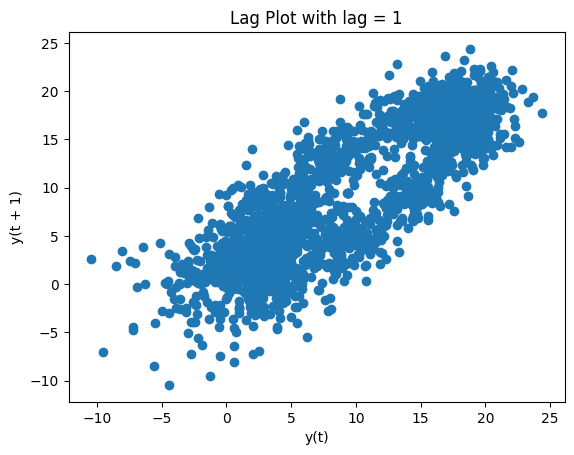

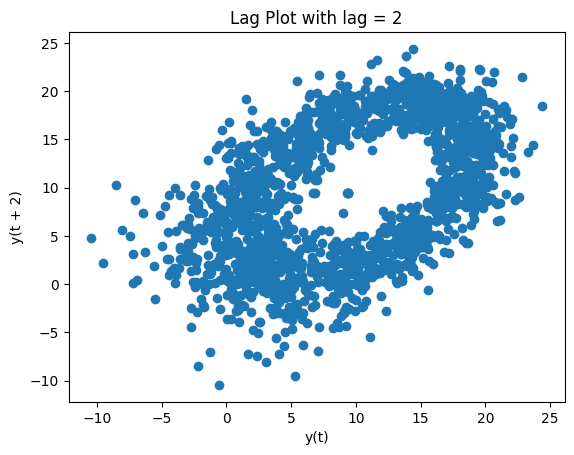

In [ ]:
for i in range(1, 3):
    pd.plotting.lag_plot(monthly_avg, lag=i)
    plt.title(f'Lag Plot with lag = {i}')
    plt.show()

Training SARIMA model

In [ ]:
monthly_avg.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 1776 entries, 1876-01-31 to 2023-12-31
Freq: ME
Series name: TG
Non-Null Count  Dtype  
--------------  -----  
1776 non-null   float64
dtypes: float64(1)
memory usage: 27.8 KB


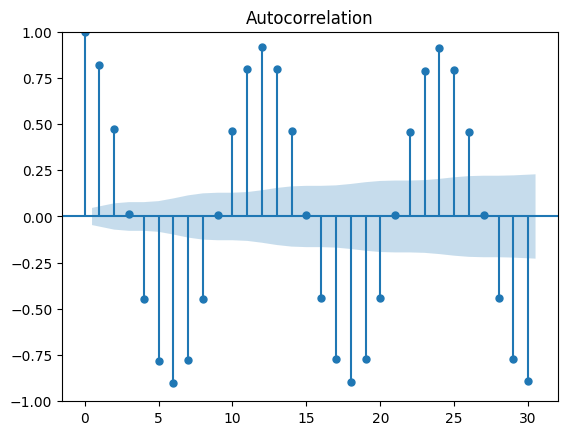

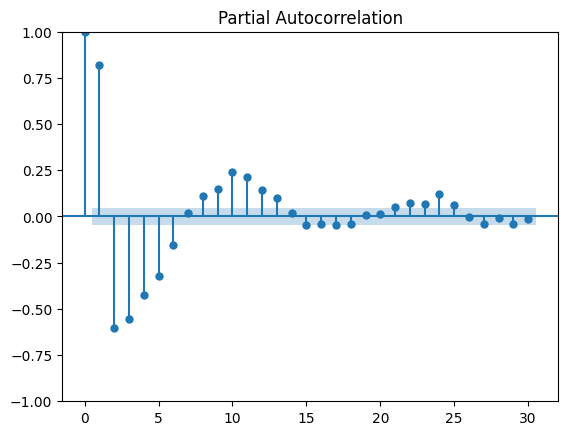

In [ ]:
plot_acf(monthly_avg, lags=30)
plot_pacf(monthly_avg, lags=30)
plt.show()

In [ ]:
adf_result = adfuller(monthly_avg)
print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])

ADF Statistic: -3.855610179334128
p-value: 0.0023869377378514557


In [ ]:
p, d, q = 3, 0, 1 #d should be zero, as data is stationary
seasonal_order = (0, 1, 1, 12)
sarima_model = sm.tsa.SARIMAX(monthly_avg, order=(p, d, q), seasonal_order=seasonal_order)
model_fit = sarima_model.fit()
print(model_fit.summary())

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:                                 TG   No. Observations:                 1776
Model:             SARIMAX(3, 0, 1)x(0, 1, 1, 12)   Log Likelihood               -3667.792
Date:                            Tue, 29 Apr 2025   AIC                           7347.585
Time:                                    08:04:20   BIC                           7380.437
Sample:                                01-31-1876   HQIC                          7359.724
                                     - 12-31-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.2398      0.022     57.430      0.000       1.198       1.282
ar.L2         -0.1948      0.037   

2024-01-31     2.042272
2024-02-29     2.839324
2024-03-31     5.978569
2024-04-30    10.596701
2024-05-31    15.657083
2024-06-30    19.053640
2024-07-31    20.709691
2024-08-31    19.986164
2024-09-30    16.222545
2024-10-31    11.270684
2024-11-30     6.328084
2024-12-31     3.106182
2025-01-31     1.788032
2025-02-28     2.726519
Freq: ME, Name: predicted_mean, dtype: float64


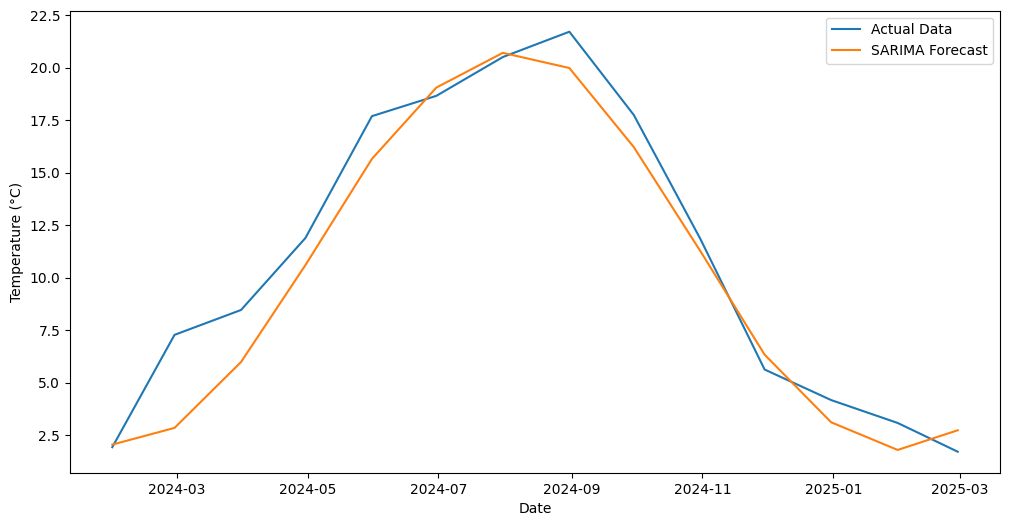

In [ ]:
forecast = model_fit.get_forecast(steps=14)  # Forecast the next 14 periods
forecast_mean = forecast.predicted_mean
print(forecast_mean)

# Plot the actual data and the forecast
plt.figure(figsize=(12, 6))
plt.plot(ts_test, label='Actual Data')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.plot(forecast_mean, label='SARIMA Forecast')
plt.legend()
plt.show()

In [ ]:
rmse = np.sqrt(mean_squared_error(ts_test, forecast_mean))
r2 = r2_score(ts_test, forecast_mean)

print(f"RMSE: {rmse}")
print(f"R² Score: {r2}")

RMSE: 1.7282756756977609
R² Score: 0.9388085467817179


In [ ]:
# create future forecast dates
def create_dates(start,months):
    v = pd.date_range(start=start, periods=months+1, freq='ME', inclusive='right')
    fourteen_month_forecast = pd.DataFrame(index=v)
    return fourteen_month_forecast

In [ ]:
df_training.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54056 entries, 0 to 54055
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   DATE    54056 non-null  datetime64[ns]
 1   TG      54056 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 1.2 MB


In [ ]:
monthly_avg.head()

,TG
DATE,
1876-01-31,-2.070968
1876-02-29,2.389655
1876-03-31,4.964516
1876-04-30,9.833333
1876-05-31,10.270968


In [ ]:
monthly_avg = monthly_avg.to_frame()

In [ ]:
ts_test.tail()

,TG
DATE,
2024-10-31,11.851613
2024-11-30,5.620000
2024-12-31,4.164516
2025-01-31,3.074194
2025-02-28,1.703571


In [ ]:
ts_test = ts_test.to_frame()

In [ ]:
# data transformation
def data_transformation(train_tract1,test_tract1):
    scaler = MinMaxScaler()
    train_tract1_scaled = scaler.fit_transform(train_tract1)
    test_tract1_scaled = scaler.fit_transform(test_tract1)
    train_tract1_scaled_df = pd.DataFrame(train_tract1_scaled, index = train_tract1.index, columns=[train_tract1.columns[0]])
    test_tract1_scaled_df = pd.DataFrame(test_tract1_scaled,
                                         index = test_tract1.index, columns=[test_tract1.columns[0]])
    return train_tract1_scaled_df, test_tract1_scaled_df, scaler

In [ ]:
# feature builder - This section creates feature set with lag number of predictors--Creating features using lagged data
def timeseries_feature_builder(df, lag):
    if len(df) <= lag:
      print("⚠️ Not enough data for the given lag size:", lag, "got", len(df))
      return pd.DataFrame()
    df_copy = df.copy()
    for i in range(1,lag):
        df_copy['lag'+str(i)] = df.shift(i)
    return df_copy

In [ ]:
# preprocessing -- drop null values and make arrays
def make_arrays(train_tract1,test_tract1):
    X_train_tract1_array = train_tract1.dropna().drop(train_tract1.columns[0], axis=1).values
    y_train_tract1_array = train_tract1.dropna()[train_tract1.columns[0]].values
    X_test_tract1_array = test_tract1.dropna().drop(test_tract1.columns[0], axis=1).values
    y_test_tract1_array = test_tract1.dropna()[test_tract1.columns[0]].values
    return X_train_tract1_array, y_train_tract1_array, X_test_tract1_array, y_test_tract1_array

In [ ]:
# Define LSTM model
def lstm_model(units, trainX, testX, y_train_tract1_array, y_test_tract1_array):
    model = Sequential()
    model.add(LSTM(units,return_sequences=True, input_shape=(trainX.shape[1],trainX.shape[2]),kernel_initializer='lecun_uniform'))
    model.add(Dropout(0.2))
    model.add(LSTM(units, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(units)) # return_sequences False by default
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

    model.fit(trainX, y_train_tract1_array, batch_size=120, epochs=100, validation_data=(testX, y_test_tract1_array), verbose=0)
    return model

In [ ]:
# validation result
def valid_result(model, testX, y_test_tract1_array, scaler, ts_test, lag):
    testPredict = model.predict(testX)
    rSquare_test = r2_score(y_test_tract1_array, testPredict)
    print('Test R-squared is: %f'%rSquare_test)
    testPredict = scaler.inverse_transform(testPredict)
    test_tract1_pred = ts_test.iloc[lag:].copy()
    test_tract1_pred['Forecast'] = testPredict
    return test_tract1_pred

In [ ]:
def valid_result(model, testX, y_test_tract1_array, scaler, ts_test, lag):
    testPredict = model.predict(testX)

    # Inverse transform both predictions and actual values
    testPredict_inv = scaler.inverse_transform(testPredict)
    y_test_inv = scaler.inverse_transform(y_test_tract1_array.reshape(-1, 1))

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_test_inv, testPredict_inv))
    r2 = r2_score(y_test_inv, testPredict_inv)

    print(f'Test RMSE: {rmse:.2f}')
    print(f'Test R² Score: {r2:.4f}')

    # Prepare the prediction DataFrame
    test_tract1_pred = ts_test.iloc[lag:].copy()
    test_tract1_pred['Forecast'] = testPredict_inv

    return test_tract1_pred

In [ ]:
# multi step future forecast for next days number of months.
def forecast(model, testX, test_tract1, lag, scaler, months):
    fourteen_months = []
    new0 = testX[-1]
    last = test_tract1.iloc[-1]
    new_predict = last.iloc[0]
    new_array = np.insert(new0, 0, new_predict)
    new_array = np.delete(new_array, -1)
    new_array_reshape = np.reshape(new_array, (-1,1,lag))
    new_predict = model.predict(new_array_reshape)
    temp_predict = scaler.inverse_transform(new_predict)
    fourteen_months.append(temp_predict[0][0].round(2))

    for i in range(1,months):
        new_array = np.insert(new_array, 0, new_predict)
        new_array = np.delete(new_array, -1)
        new_array_reshape = np.reshape(new_array, (-1,1,lag))
        new_predict = model.predict(new_array_reshape)
        temp_predict = scaler.inverse_transform(new_predict)
        fourteen_months.append(temp_predict[0][0].round(2))
    return fourteen_months

In [ ]:
def temp_lstm(train_tract1, test_tract1, lag, months):

    if len(train_tract1) < lag + 1:
      raise ValueError(f"Not enough data points ({len(train_tract1)}) for the chosen lag ({lag})")

    fourteen_month_forecast_lstm = create_dates('2024-01-31',months)
    print(fourteen_month_forecast_lstm)
    # preprocessing
    train_tract1_scaled_df, test_tract1_scaled_df, scaler = data_transformation(train_tract1,test_tract1)
    train_tract1 = timeseries_feature_builder(train_tract1_scaled_df, lag+1)
    test_tract1 = timeseries_feature_builder(test_tract1_scaled_df, lag+1)
    X_train_tract1_array, y_train_tract1_array, X_test_tract1_array, y_test_tract1_array = make_arrays(train_tract1,
                                                                                                           test_tract1)
    trainX = np.reshape(X_train_tract1_array, (X_train_tract1_array.shape[0],1,X_train_tract1_array.shape[1]))
    testX = np.reshape(X_test_tract1_array, (X_test_tract1_array.shape[0],1,X_test_tract1_array.shape[1]))

    # LSTM modelling & forecast
    model = lstm_model(30, trainX, testX, y_train_tract1_array, y_test_tract1_array)
    test_tract1_pred = valid_result(model, testX, y_test_tract1_array, scaler, ts_test, lag)
    print("Model type:", type(model))
    fourteen_months = forecast(model, testX, test_tract1, lag, scaler, months)
    fourteen_months = np.array(fourteen_months)
    forecast_df = pd.DataFrame({
      'Forecast': fourteen_months
    }, index=fourteen_month_forecast_lstm.index)
    print(forecast_df)

    # plot result
    plt.figure(figsize=(12,6))
    plt.plot(ts_test, label='Actual Data')
    plt.plot(forecast_df, label='Forecast')
    plt.ylabel('Temperature(°C)')
    plt.xlabel('Date')
    plt.legend(loc='upper right')
    plt.show()

    return(fourteen_months)

Empty DataFrame
Columns: []
Index: [2024-02-29 00:00:00, 2024-03-31 00:00:00, 2024-04-30 00:00:00, 2024-05-31 00:00:00, 2024-06-30 00:00:00, 2024-07-31 00:00:00, 2024-08-31 00:00:00, 2024-09-30 00:00:00, 2024-10-31 00:00:00, 2024-11-30 00:00:00, 2024-12-31 00:00:00, 2025-01-31 00:00:00, 2025-02-28 00:00:00, 2025-03-31 00:00:00]


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step
Test RMSE: 2.34
Test R² Score: 0.9029
Model type: <class 'keras.src.models.sequential.Sequential'>
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
             Forecast
2024-02-29   8.190000
2024-03-31  12.520000
2024-04-30  16.830000
2024-05-31  19.520000
2024-06-30  19.540001
2024-07-31  18.490000
2024-08-31  15.950000
2024-09-30  12.310000
2024-10-31   9.300000
2024-11-30   7.510000
2024-12-31   7.330000
2025-01-31   8.720000
2025-02-28  11.190000
2025-03-31  14.120000

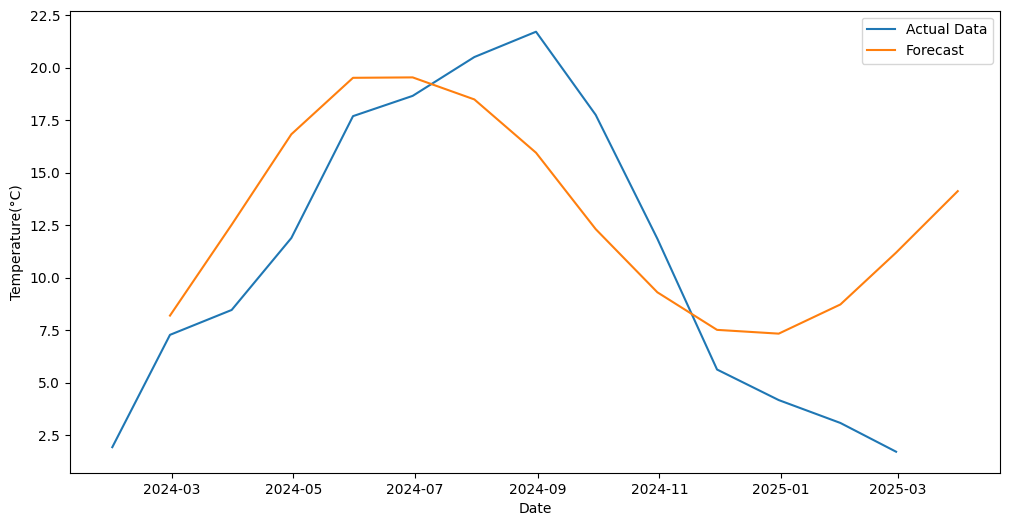

In [ ]:
 lstm_prediction = temp_lstm(monthly_avg, ts_test, 4, 14)

In [ ]:
scaler = MinMaxScaler()
y_pred_rescaled = scaler.inverse_transform(y_pred)
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))

NameError: name 'y_pred' is not defined